# Price Utility — Rolling 48h Example Notebook

This notebook demonstrates the public API from `utils/prices_utils.py`.

| Function | What it does |
|---|---|
| `get_48h_prices_forecast(secrets_dir="secrets", allow_fallback=True)` | Returns a strict rolling 48-hour UTC window in 15-minute resolution |

**Returned columns**
- `time` — UTC timestamp
- `price_eur_mwh` — price in EUR/MWh
- `price_cent_kwh` — price in ct/kWh
- `source` — `entsoe_api`, `fallback_partial`, or `fallback_unavailable`
- `note` — optional explanation for fallback paths

## What These API Prices Mean

The values come from the ENTSOE day-ahead market for the `DE_LU` bidding zone.

- They are **wholesale electricity market prices**, not a final residential tariff.
- They are quoted in **EUR/MWh** by the market and converted here to **ct/kWh**.
- They do **not** include grid fees, taxes, supplier margin, or retail markups.
- The utility normalizes output to a strict rolling UTC window at 15-minute frequency.

Window semantics: output starts at `now.floor("15min")` and contains exactly `192` rows (48h).

Run from project root or keep the path bootstrap cell below.

In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from utils.prices_utils import get_48h_prices_forecast

print(f"Project root: {root}")

prices = get_48h_prices_forecast()

print(f"Rows   : {len(prices)}")
print(f"Start  : {prices['time'].iloc[0]}")
print(f"End    : {prices['time'].iloc[-1]}")
print(f"Source : {prices['source'].unique()}")
print(f"Columns: {list(prices.columns)}")
print()
prices.head(8)

Project root: /Users/joscham/dsai/repos/hems-automation
Rows   : 192
Start  : 2026-03-30 14:45:00+00:00
End    : 2026-04-01 14:30:00+00:00
Source : ['entsoe_api' 'calculated_prev_day']
Columns: ['time', 'price_eur_mwh', 'price_cent_kwh', 'source']



,time,price_eur_mwh,price_cent_kwh,source
0,2026-03-30 14:45:00+00:00,76.39,7.639,entsoe_api
1,2026-03-30 15:00:00+00:00,45.46,4.546,entsoe_api
2,2026-03-30 15:15:00+00:00,65.46,6.546,entsoe_api
3,2026-03-30 15:30:00+00:00,93.74,9.374,entsoe_api
4,2026-03-30 15:45:00+00:00,112.09,11.209,entsoe_api
5,2026-03-30 16:00:00+00:00,85.00,8.500,entsoe_api
6,2026-03-30 16:15:00+00:00,104.52,10.452,entsoe_api
7,2026-03-30 16:30:00+00:00,109.38,10.938,entsoe_api


In [14]:
# Time-grid sanity checks
delta = prices["time"].diff().dropna()
span_h = (prices["time"].iloc[-1] - prices["time"].iloc[0]).total_seconds() / 3600.0

print("Unique step sizes:", delta.unique())
print("Expected rows   : 192")
print("Actual rows     :", len(prices))
print(f"Window span (h) : {span_h:.2f} (expected 47.75)")
print("Timezone        :", prices["time"].dt.tz)
print("Has note column :", "note" in prices.columns)

Unique step sizes: <TimedeltaArray>
['0 days 00:15:00']
Length: 1, dtype: timedelta64[ns]
Expected rows   : 192
Actual rows     : 192
Window span (h) : 47.75 (expected 47.75)
Timezone        : UTC
Has note column : False


## Output behavior and fallback modes

`get_48h_prices_forecast()` always returns a **192-row rolling UTC window** (48h at 15-minute resolution).

Possible `source` values:
- `entsoe_api` — full API coverage for the rolling window
- `fallback_partial` — partial coverage; some slots could not be resolved directly from API points
- `fallback_unavailable` — API request failed and a NaN fallback frame was returned

Notes:
- The first timestamp is `now.floor("15min")` at call time.
- The last timestamp is `first + 47h45m`.
- If fallback is used, a `note` column may contain diagnostic detail.

In [15]:
df = prices.copy()

print("Shape:", df.shape)
print()
print("dtypes:")
print(df.dtypes)
print()
df.describe(include="all")

Shape: (192, 4)

dtypes:
time              datetime64[ns, UTC]
price_eur_mwh                 float64
price_cent_kwh                float64
source                         object
dtype: object



,time,price_eur_mwh,price_cent_kwh,source
count,192,192.000000,192.000000,192
unique,NaN,NaN,NaN,2
top,NaN,NaN,NaN,entsoe_api
freq,NaN,NaN,NaN,125
mean,2026-03-31 14:37:30+00:00,110.152448,11.015245,NaN
min,2026-03-30 14:45:00+00:00,40.070000,4.007000,NaN
25%,2026-03-31 02:41:15+00:00,93.052500,9.305250,NaN
50%,2026-03-31 14:37:30+00:00,104.020000,10.402000,NaN
75%,2026-04-01 02:33:45+00:00,138.325000,13.832500,NaN
max,2026-04-01 14:30:00+00:00,203.400000,20.340000,NaN


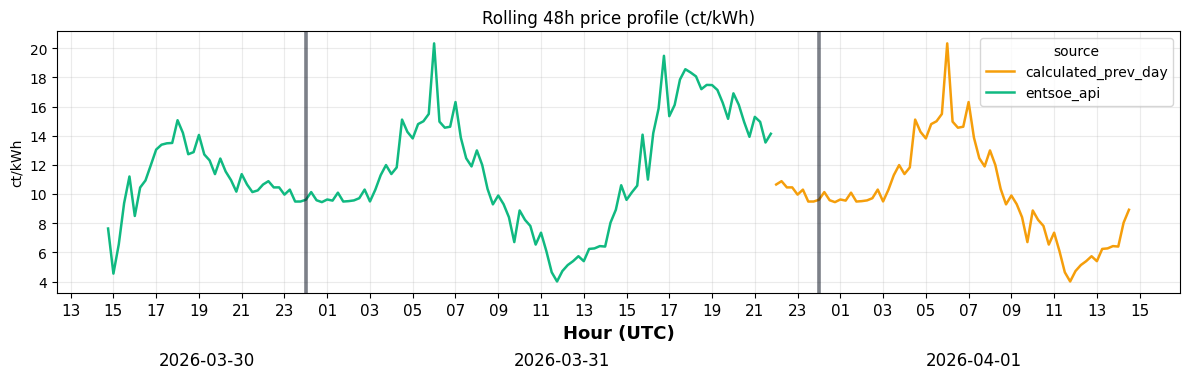

In [18]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))

color_map = {
    "entsoe_api": "#10b981",
    "calculated_prev_day": "#f59e0b",
    "fallback_unavailable": "#ef4444",
}

for src, grp in df.sort_values("time").groupby("source", dropna=False):
    label = str(src) if pd.notna(src) else "unknown"
    color = color_map.get(label, "#6b7280")
    ax.plot(
        grp["time"],
        grp["price_cent_kwh"],
        color=color,
        linewidth=1.8,
        label=label,
    )

sources = sorted(df["source"].dropna().unique().tolist())
source_str = ", ".join(sources) if sources else "unknown"
ax.set_title(f"Rolling 48h price profile (ct/kWh)")
ax.set_xlabel("Hour (UTC)", fontsize=13, fontweight="bold")
ax.set_ylabel("ct/kWh")

# X-axis: major ticks every 2 hours with hour only.
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
ax.tick_params(axis="x", labelsize=11)

# Draw thick separators at UTC day boundaries and label each date once.
start = df["time"].min().floor("D")
end = df["time"].max().ceil("D")
day_starts = pd.date_range(start=start, end=end, freq="D", tz="UTC")

for ds in day_starts:
    if df["time"].min() < ds < df["time"].max():
        ax.axvline(ds, color="#111827", linewidth=2.6, alpha=0.55)

for i in range(len(day_starts) - 1):
    seg_start = max(day_starts[i], df["time"].min())
    seg_end = min(day_starts[i + 1], df["time"].max())
    if seg_end > seg_start:
        mid = seg_start + (seg_end - seg_start) / 2
        ax.text(
            mid,
            -0.22,
            day_starts[i].strftime("%Y-%m-%d"),
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=12,
        )

ax.grid(alpha=0.25)
ax.legend(title="source")
fig.tight_layout()
plt.show()